
image 1/1 /tf/ramp-data/sample_2/yolo_v11/images/train/OAM-619224-523266-20.jpg: 256x256 13 rooftops, 6.4ms
Speed: 0.5ms preprocess, 6.4ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)


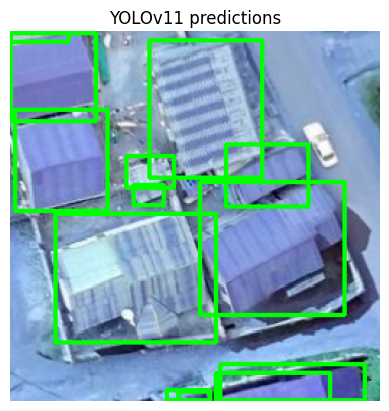

In [2]:
# Standard library imports
import os
import time
import warnings
import ultralytics
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# load the YOLOv8 model
model = YOLO(f"{os.getcwd()}/yolo11n-seg.pt")

IMAGE_PATH = 'ramp-data/sample_2/yolo_v11/images/train/OAM-619224-523266-20.jpg'
# run the model on the image
results = model.predict(source=IMAGE_PATH, conf=0.25)
predicted_boxes = results[0].boxes.xyxy


# read in the image for visualization
image = cv2.imread(IMAGE_PATH, cv2.IMREAD_COLOR)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# use cv2 to visualize the bounding boxes on the image
for box in predicted_boxes:
 cv2.rectangle(image, (int(box[0]), int(box[1])), (int(box[2]), int(box[3])), (0, 255, 0), 2)

# Display the image using Matplotlib
plt.imshow(image)
plt.axis('off') # Optional: remove axes
plt.title('YOLOv11 predictions') # Optional: add a title
plt.show()
